# Step 20: Multi-Asset Risk-Averse Regime Analysis

## 🎯 Objective:
Menerapkan 4 varian tingkat konservatisme (Thresholding) menggunakan **seluruh dataset** (Multi-Asset).
Model ini dirancang untuk meminimalkan **False Bullish** (Sinyal beli yang salah) sesuai prinsip "Capital Preservation".

## 🛡️ The 4 Variants (Conservativeness Levels):
1. **Standard (Threshold >= 0.50)**: Model agresif.
2. **Cautious (Threshold >= 0.65)**: Mulai menyaring sinyal ragu.
3. **Conservative (Threshold >= 0.80)**: Fokus pada keamanan modal.
4. **Ultra-Conservative (Threshold >= 0.90)**: Mode bertahan total (Paranoid).

## 🧬 Features Used (The Hybrid Matrix):
- **PCA Factors (1-5)**: Representasi pergerakan pasar crypto secara global.
- **Volatility Ratio**: Perbandingan volatilitas jangka pendek vs panjang.
- **Graph Density**: Kepadatan korelasi antar aset (Topological Risk).
- **BTC Momentum**: Indikator tren dari aset jangkar (BTC).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("🛡️ Multi-Asset Risk-Averse Environment Ready!")

🛡️ Multi-Asset Risk-Averse Environment Ready!


## 1. Multi-Asset Feature Engineering

In [2]:
# Load Data
df = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = df.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)
crypto_assets = [c for c in df.columns if c != 'PAXG-USD']
crypto_rets = returns[crypto_assets]

print(f"📊 Processing {len(crypto_assets)} assets...")

# A. PCA Features (Global Market Drivers)
scaler = StandardScaler()
pca = PCA(n_components=5)
X_hybrid = pd.DataFrame(pca.fit_transform(scaler.fit_transform(crypto_rets)), 
                        index=crypto_rets.index, 
                        columns=[f'PC{i+1}' for i in range(5)])

# B. Volatility & Momentum (BTC Specific)
X_hybrid['BTC_Vol_20'] = crypto_rets['BTC-USD'].rolling(20).std()
X_hybrid['BTC_Mom_20'] = crypto_rets['BTC-USD'].rolling(20).mean()

# C. Graph Density (Topological Risk)
def calculate_graph_density_series(ret_df, window=20, threshold=0.5):
    rolling_corr = ret_df.rolling(window).corr()
    densities = []
    dates = []
    v = len(ret_df.columns)
    max_edges = v * (v - 1) / 2
    valid_dates = ret_df.index[window-1:]
    for date in valid_dates:
        corr_matrix = rolling_corr.loc[date].fillna(0)
        adj_matrix = (corr_matrix > threshold).astype(int)
        edges = (adj_matrix.values.sum() - v) / 2
        densities.append(edges / max_edges if max_edges > 0 else 0)
        dates.append(date)
    return pd.Series(densities, index=dates)

X_hybrid['Graph_Density'] = calculate_graph_density_series(crypto_rets)

# D. Target Construction (BTC Return > 0.5%)
X_hybrid['Target'] = np.where(crypto_rets['BTC-USD'].shift(-1) > 0.005, 1, 0)
X_hybrid = X_hybrid.dropna()

print(f"✅ Feature Matrix Ready. Shape: {X_hybrid.shape}")

📊 Processing 24 assets...
✅ Feature Matrix Ready. Shape: (971, 9)


## 2. Training Risk-Averse Model

In [3]:
train_idx = X_hybrid.index.year < 2025
test_idx = X_hybrid.index.year == 2025

X_train, y_train = X_hybrid[train_idx].drop(columns=['Target']), X_hybrid.loc[train_idx, 'Target']
X_test, y_test = X_hybrid[test_idx].drop(columns=['Target']), X_hybrid.loc[test_idx, 'Target']

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

probs_bullish = rf_model.predict_proba(X_test)[:, 1]
print("✅ Model trained on Multi-Asset data.")

✅ Model trained on Multi-Asset data.


## 3. Comparison of 4 Conservativeness Levels

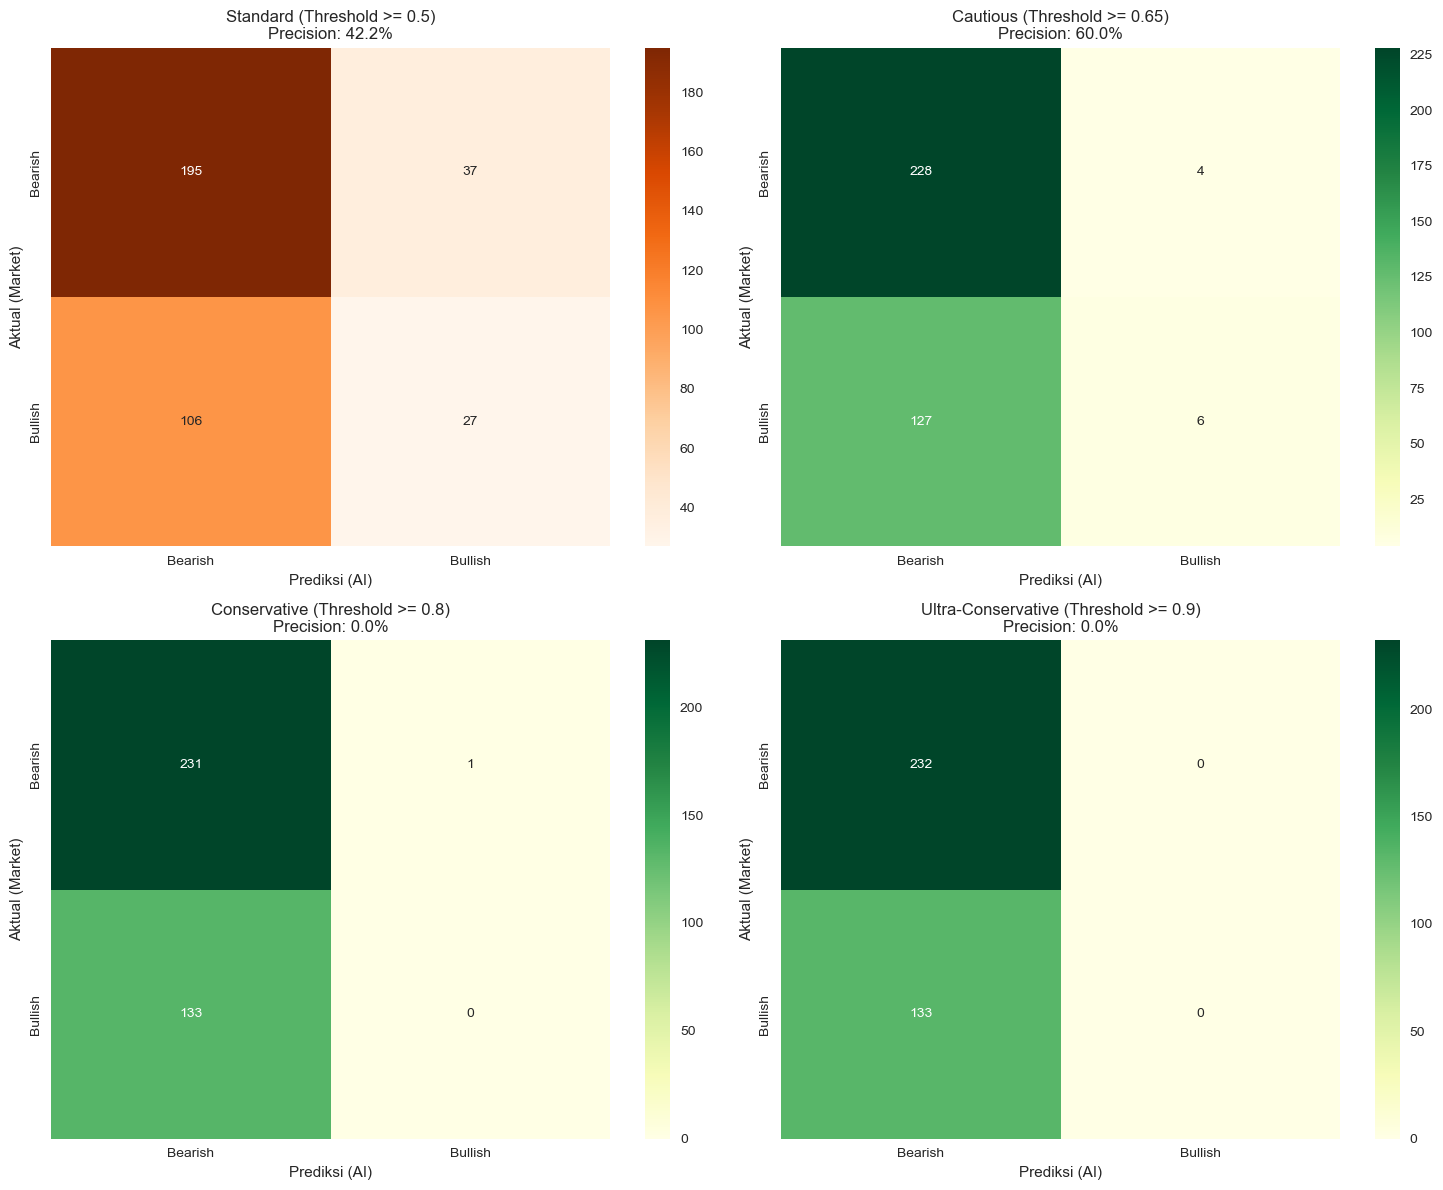

In [4]:
thresholds = {
    'Standard': 0.50,
    'Cautious': 0.65,
    'Conservative': 0.80,
    'Ultra-Conservative': 0.90
}

results = []
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, thresh) in enumerate(thresholds.items()):
    y_pred = (probs_bullish >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    
    # Metrik Pendukung
    prec = precision_score(y_test, y_pred, zero_division=0)
    danger_fp = cm[0, 1] if cm.shape == (2,2) else 0
    success_tp = cm[1, 1] if cm.shape == (2,2) else 0
    
    results.append({
        'Variant': name,
        'Threshold': thresh,
        'Precision': prec,
        'Dangerous_False_Bullish': danger_fp,
        'Captured_True_Bullish': success_tp
    })
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges' if name=='Standard' else 'YlGn', ax=axes[i], 
                xticklabels=['Bearish', 'Bullish'], 
                yticklabels=['Bearish', 'Bullish'])
    axes[i].set_title(f"{name} (Threshold >= {thresh})\nPrecision: {prec:.1%}")
    axes[i].set_xlabel('Prediksi (AI)')
    axes[i].set_ylabel('Aktual (Market)')

plt.tight_layout()
plt.show()

## 4. Final Trade-off Analysis


--- SUMMARY TABLE: THE RISK VS OPPORTUNITY ---
           Variant  Threshold  Precision  Dangerous_False_Bullish  Captured_True_Bullish
          Standard       0.50   0.421875                       37                     27
          Cautious       0.65   0.600000                        4                      6
      Conservative       0.80   0.000000                        1                      0
Ultra-Conservative       0.90   0.000000                        0                      0


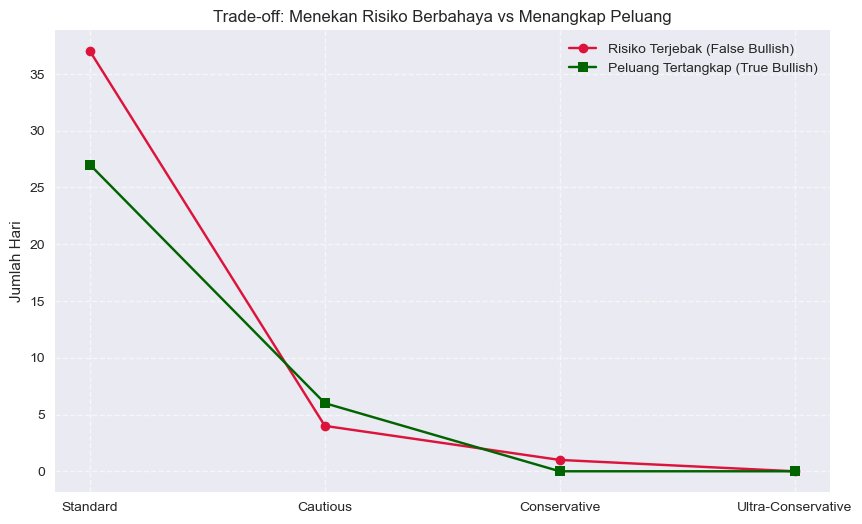

In [5]:
analysis_df = pd.DataFrame(results)
print("\n--- SUMMARY TABLE: THE RISK VS OPPORTUNITY ---")
print(analysis_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.plot(analysis_df['Variant'], analysis_df['Dangerous_False_Bullish'], 
         marker='o', color='crimson', label='Risiko Terjebak (False Bullish)')
plt.plot(analysis_df['Variant'], analysis_df['Captured_True_Bullish'], 
         marker='s', color='darkgreen', label='Peluang Tertangkap (True Bullish)')
plt.title('Trade-off: Menekan Risiko Berbahaya vs Menangkap Peluang')
plt.ylabel('Jumlah Hari')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()